2025-12-04 15:59:25.736276: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764860365.744380 2221448 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764860365.746932 2221448 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-04 15:59:25.756109: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


원본 csi(CFR) shape: (1000, 64)
원본 velocity shape: (3, 1)
전체 feature 데이터 형태: (1000, 67)
Train 개수: 900
Test  개수: 100
학습 데이터 X 형태: (889, 10, 67)
학습 데이터 Y 형태: (889, 64)


I0000 00:00:1764860369.299301 2221448 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9322 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:2b:00.0, compute capability: 8.6


학습 시작...
Epoch 1/50


I0000 00:00:1764860370.547801 2221966 cuda_dnn.cc:529] Loaded cuDNN version 90101


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1744 - val_loss: 0.0160
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0524 - val_loss: 0.0114
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0411 - val_loss: 0.0077
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0307 - val_loss: 0.0051
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0283 - val_loss: 0.0037
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0275 - val_loss: 0.0032
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0243 - val_loss: 0.0029
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0188 - val_loss: 0.0025
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0157 - val_loss: 0.0024
Epoch 10/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0167 - val_loss: 0.0023
Epoch 11/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0191 - val_loss: 0.0024
Epoch 12/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0167 - val_loss: 0.0025

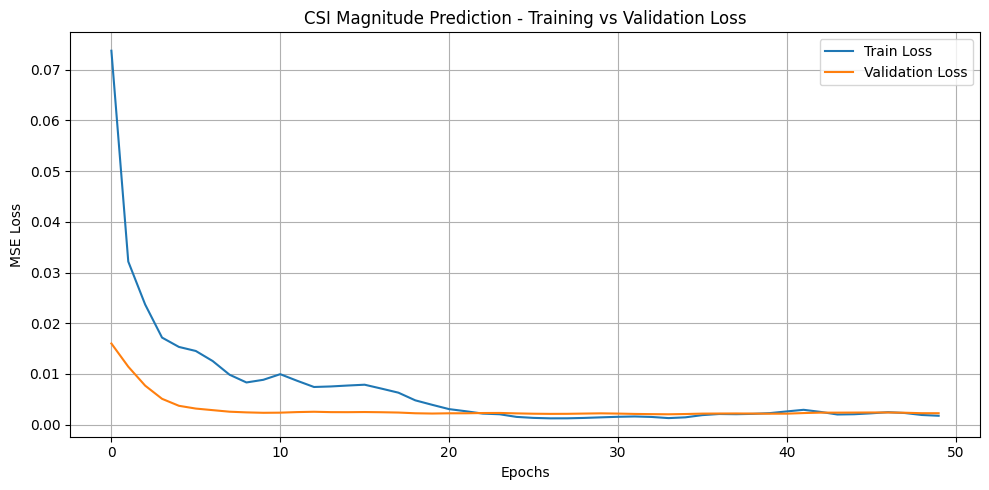

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


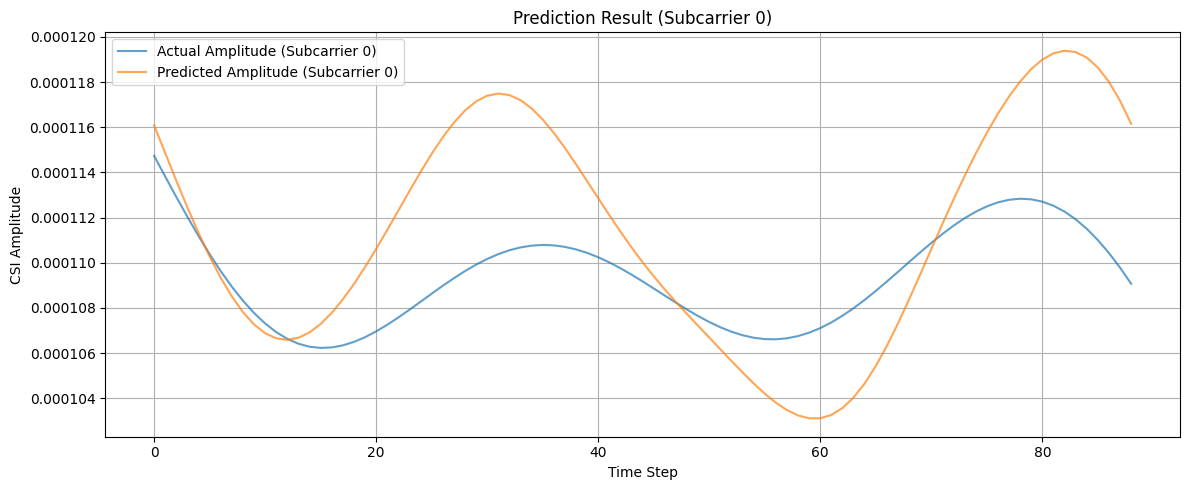

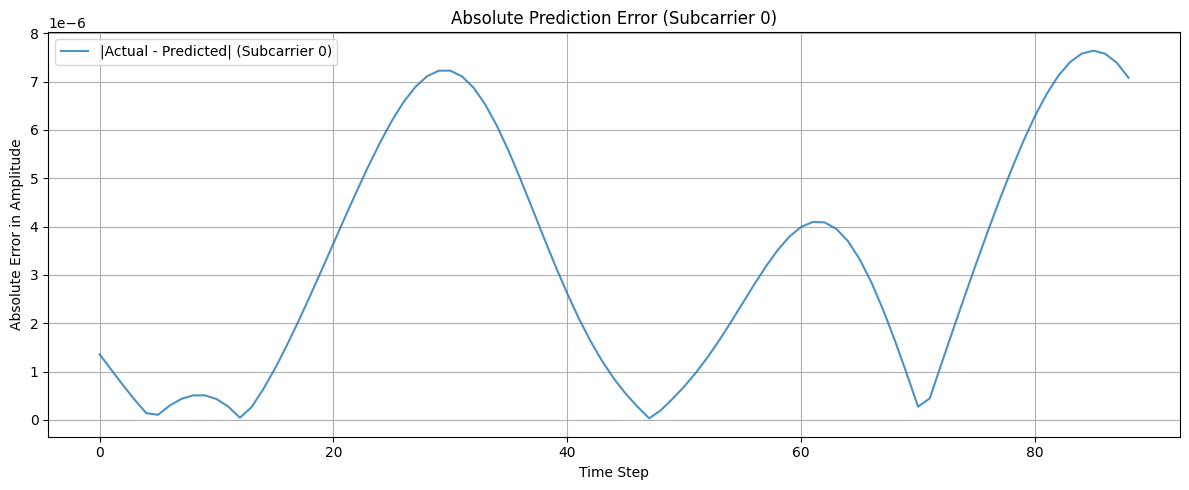

In [1]:
import scipy.io as sio
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt
import os

# -----------------------------------------
# (선택) 재현성을 위해 시드 고정
# -----------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# -----------------------------------------
# 1) 데이터 로드
# -----------------------------------------
mat_path = "1_munich_csi_data.mat"  # 업로드한 파일 이름

if not os.path.exists(mat_path):
    print(f"에러: 파일을 찾을 수 없습니다. 경로를 확인하세요: {mat_path}")
else:
    data = sio.loadmat(mat_path)

    # 실제 파일 내부 변수 이름에 맞게 사용
    csi = data["CFR"]          # (N, 64) complex64
    velocity = data["velocity"]  # (3, 1) float32

    print("원본 csi(CFR) shape:", csi.shape)        # (1000, 64)
    print("원본 velocity shape:", velocity.shape)   # (3, 1)

    # -----------------------------------------
    # 2) CSI -> 진폭(Magnitude) 변환
    # -----------------------------------------
    # csi: (N, 64)
    N, F = csi.shape           # N=1000, F=64

    # 복소수 CSI의 절댓값(진폭)
    csi_amp = np.abs(csi)      # (N, 64)

    # -----------------------------------------
    # 2-1) rx_pos 비슷하게 만들기 (velocity를 N번 반복)
    #      velocity: (3, 1) -> (1, 3) -> (N, 3)
    # -----------------------------------------
    vel_vec = velocity.reshape(1, -1)   # (1, 3)
    rx_pos = np.repeat(vel_vec, N, axis=0)  # (N, 3)

    # Feature 결합: [진폭(64), "위치 비슷한 것"(3)] = 67차원
    features = np.concatenate([csi_amp, rx_pos], axis=1)
    print(f"전체 feature 데이터 형태: {features.shape}")  # (N, 67)

    # -----------------------------------------
    # 3) Train / Test 분할 (90% / 10%)
    # -----------------------------------------
    split_percentage = 0.9
    split_point = round(N * split_percentage)

    train_feat = features[:split_point]
    test_feat  = features[split_point:]

    print("Train 개수:", train_feat.shape[0])
    print("Test  개수:", test_feat.shape[0])

    # -----------------------------------------
    # 4) 스케일링 (0~1 범위로 정규화)
    # -----------------------------------------
    scaler = MinMaxScaler()
    scaler.fit(train_feat)

    scaled_train = scaler.transform(train_feat)
    scaled_test  = scaler.transform(test_feat)

    # -----------------------------------------
    # 5) 시계열 윈도우 생성 함수
    # -----------------------------------------
    def timeseries_preprocessing(scaled_train, scaled_test, lags, amp_dim):
        """
        입력(X): 과거 lags개 시점의 [진폭(F) + "위치"(3)] -> (lags, F+3)
        출력(Y): 다음 시점의 [진폭(F)]만 -> (F,)
        """
        # Train
        X_tr, Y_tr = [], []
        for t in range(len(scaled_train) - lags - 1):
            X_tr.append(scaled_train[t : t+lags, :])
            Y_tr.append(scaled_train[t+lags, :amp_dim])  # 앞 amp_dim개(진폭)만 예측 타겟

        # Test
        X_te, Y_te = [], []
        for t in range(len(scaled_test) - lags - 1):
            X_te.append(scaled_test[t : t+lags, :])
            Y_te.append(scaled_test[t+lags, :amp_dim])

        return np.array(X_tr), np.array(Y_tr), np.array(X_te), np.array(Y_te)

    # 윈도우 크기 설정
    lags = 10
    amp_dim = F   # 64, 예측할 진폭 차원 수

    # 데이터셋 생성
    X_train, Y_train, X_test, Y_test = timeseries_preprocessing(
        scaled_train, scaled_test, lags, amp_dim
    )

    print("학습 데이터 X 형태:", X_train.shape)  # (samples, 10, 67)
    print("학습 데이터 Y 형태:", Y_train.shape)  # (samples, 64)

    # -----------------------------------------
    # 6) LSTM 모델 정의
    # -----------------------------------------
    n_features = X_train.shape[2]  # 67
    output_dim = Y_train.shape[1]  # 64 (진폭 개수)

    model = Sequential()
    model.add(Input(shape=(lags, n_features)))   # (10, 67)
    model.add(LSTM(256))
    model.add(Dense(output_dim))                 # 64개 진폭 예측

    model.compile(optimizer='adam', loss='mse')

    # -----------------------------------------
    # 7) 학습 시작
    # -----------------------------------------
    print("학습 시작...")
    history = model.fit(
        X_train, Y_train,
        epochs=50,
        validation_data=(X_test, Y_test),
        shuffle=False,
        verbose=1
    )

    # -----------------------------------------
    # 8) 결과 그래프 (Train / Val Loss)
    # -----------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('CSI Magnitude Prediction - Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------
    # 9) 예측 결과 시각화 (첫 번째 서브캐리어 실제 vs 예측)
    # -----------------------------------------
    Y_pred_scaled = model.predict(X_test)

    # 진폭(앞 amp_dim차원)만 복원하기 위한 스케일러 정보
    scaler_amp_min   = scaler.min_[:amp_dim]
    scaler_amp_scale = scaler.scale_[:amp_dim]

    # MinMaxScaler 내부 정의:
    # X_scaled = X * scale_ + min_
    # -> 역변환: X = (X_scaled - min_) / scale_
    Y_true = (Y_test - scaler_amp_min) / scaler_amp_scale
    Y_pred = (Y_pred_scaled - scaler_amp_min) / scaler_amp_scale

    # 그래프 1: 서브캐리어 0 실제/예측 비교
    plt.figure(figsize=(12, 5))
    plt.plot(Y_true[:, 0], label='Actual Amplitude (Subcarrier 0)', alpha=0.7)
    plt.plot(Y_pred[:, 0], label='Predicted Amplitude (Subcarrier 0)', alpha=0.7)
    plt.title('Prediction Result (Subcarrier 0)')
    plt.xlabel('Time Step')
    plt.ylabel('CSI Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------
    # 10) 추가 그래프: 서브캐리어 0의 "절대 오차" 시퀀스
    # -----------------------------------------
    error_sc0 = np.abs(Y_true[:, 0] - Y_pred[:, 0])

    plt.figure(figsize=(12, 5))
    plt.plot(error_sc0, label='|Actual - Predicted| (Subcarrier 0)', alpha=0.8)
    plt.title('Absolute Prediction Error (Subcarrier 0)')
    plt.xlabel('Time Step')
    plt.ylabel('Absolute Error in Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Experiment A: LSTM Units (Lag=10)
  Units= 32 -> MAE-MAPE: 3.69%, RMSE-MAPE: 4.65%, R2: 0.370
  Units= 64 -> MAE-MAPE: 2.60%, RMSE-MAPE: 3.26%, R2: 0.707
  Units=128 -> MAE-MAPE: 2.11%, RMSE-MAPE: 2.62%, R2: 0.754
  Units=256 -> MAE-MAPE: 1.89%, RMSE-MAPE: 2.36%, R2: 0.819
  Units=512 -> MAE-MAPE: 2.81%, RMSE-MAPE: 3.48%, R2: 0.606

Experiment B: Lags (Units=256)
  Lag= 3 -> MAE-MAPE: 1.80%, RMSE-MAPE: 2.22%, R2: 0.842
  Lag= 5 -> MAE-MAPE: 1.74%, RMSE-MAPE: 2.20%, R2: 0.865
  Lag=10 -> MAE-MAPE: 2.05%, RMSE-MAPE: 2.57%, R2: 0.751
  Lag=15 -> MAE-MAPE: 2.10%, RMSE-MAPE: 2.63%, R2: 0.729
  Lag=20 -> MAE-MAPE: 2.06%, RMSE-MAPE: 2.56%, R2: 0.781


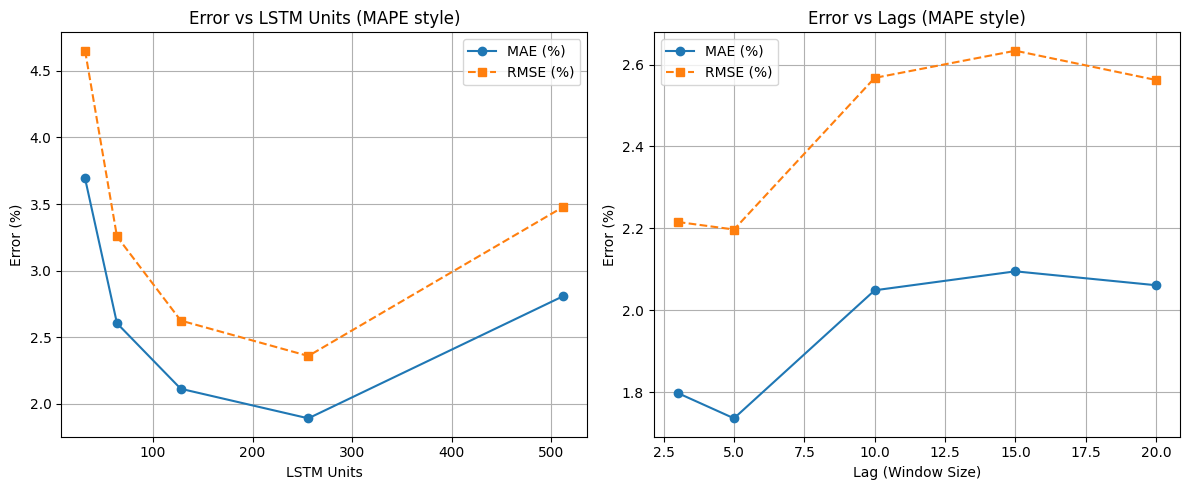

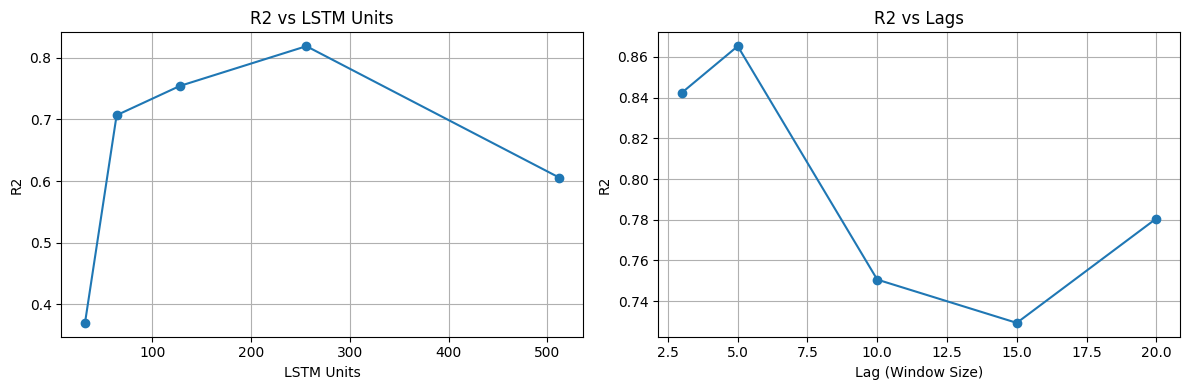

In [3]:
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

# -------------------------------------------------------
# 0. 전역 설정: 진폭 차원 수 (예: 64 서브캐리어)
# -------------------------------------------------------
AMP_DIM = 64   # = 예측 대상인 서브캐리어 진폭 차원 수

# -------------------------------------------------------
# 1. 진폭 부분만 inverse-scaling 하는 스케일러
# -------------------------------------------------------
def make_amp_scaler(scaler_all, amp_dim=AMP_DIM):
    """67차원(진폭64+위치3) scaler에서 앞 amp_dim개(진폭)만 떼서 복원용 scaler 생성"""
    scaler_amp = MinMaxScaler()
    scaler_amp.n_features_in_ = amp_dim
    scaler_amp.feature_range  = scaler_all.feature_range

    scaler_amp.min_        = scaler_all.min_[:amp_dim].copy()
    scaler_amp.scale_      = scaler_all.scale_[:amp_dim].copy()
    scaler_amp.data_min_   = scaler_all.data_min_[:amp_dim].copy()
    scaler_amp.data_max_   = scaler_all.data_max_[:amp_dim].copy()
    scaler_amp.data_range_ = scaler_all.data_range_[:amp_dim].copy()
    return scaler_amp

# -------------------------------------------------------
# 2. metric 계산
# -------------------------------------------------------
def compute_metrics(model, X, Y, scaler_all, amp_dim=AMP_DIM):
    """
    model      : 학습된 LSTM
    X, Y       : (scaled) 테스트 데이터 (Y는 진폭 amp_dim개만 포함)
    scaler_all : 67차원 전체에 대해 fit된 MinMaxScaler
    return     : dict 형태의 각종 지표
    """
    # 1) 예측 (scaled 공간)
    Y_pred_scaled = model.predict(X, verbose=0)

    # 2) 진폭(앞 amp_dim차원)만 inverse transform
    scaler_amp = make_amp_scaler(scaler_all, amp_dim)
    Y_true = scaler_amp.inverse_transform(Y)            # (N, amp_dim)
    Y_pred = scaler_amp.inverse_transform(Y_pred_scaled)

    # 3) 기본 지표
    mae = metrics.mean_absolute_error(Y_true, Y_pred)
    mse = metrics.mean_squared_error(Y_true, Y_pred)
    rmse = np.sqrt(mse)
    r2 = metrics.r2_score(Y_true, Y_pred)

    # 4) 비율 지표들
    data_range = np.max(Y_true) - np.min(Y_true) + 1e-8  # 0 방지
    mae_percent = 100 * mae / data_range
    rmse_percent = 100 * rmse / data_range

    mean_abs = np.mean(np.abs(Y_true)) + 1e-8
    mae_percent_mape_style = 100 * mae / mean_abs
    rmse_percent_mape_style = 100 * rmse / mean_abs

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "mae_percent": mae_percent,
        "rmse_percent": rmse_percent,
        "mae_percent_mape_style": mae_percent_mape_style,
        "rmse_percent_mape_style": rmse_percent_mape_style,
    }

# -------------------------------------------------------
# 3. units / lags에 따라 모델 학습 + metric 리턴
# -------------------------------------------------------
def run_experiment_metrics(units, lags, scaled_train, scaled_test, scaler_all,
                           amp_dim=AMP_DIM, epochs=15):
    """
    units : LSTM 유닛 수
    lags  : 윈도우 길이
    """
    # ⚠️ 여기서 timeseries_preprocessing은
    #    timeseries_preprocessing(scaled_train, scaled_test, lags, amp_dim)
    #    형태로 정의되어 있다고 가정 (앞에서 munich_csi용으로 수정한 버전)
    X_train, Y_train, X_test, Y_test = timeseries_preprocessing(
        scaled_train, scaled_test, lags, amp_dim
    )

    n_features = X_train.shape[2]  # 67
    output_dim = Y_train.shape[1]  # amp_dim(=64)

    # LSTM 모델 정의
    model = Sequential()
    model.add(Input(shape=(lags, n_features)))
    model.add(LSTM(units))
    model.add(Dense(output_dim))
    model.compile(optimizer='adam', loss='mse')

    # 학습
    model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=32,
        verbose=0,
        shuffle=False
    )

    # metric 계산
    metrics_dict = compute_metrics(model, X_test, Y_test, scaler_all, amp_dim)
    return metrics_dict

# =======================================================
# 실험 A: LSTM 유닛 수 변화에 따른 지표
# =======================================================
units_list = [32, 64, 128, 256, 512]
fixed_lag = 10
mae_mape_units = []
rmse_mape_units = []
r2_units = []

print(f"Experiment A: LSTM Units (Lag={fixed_lag})")
for u in units_list:
    m = run_experiment_metrics(u, fixed_lag, scaled_train, scaled_test, scaler,
                               amp_dim=AMP_DIM, epochs=15)
    mae_mape_units.append(m["mae_percent_mape_style"])
    rmse_mape_units.append(m["rmse_percent_mape_style"])
    r2_units.append(m["r2"])
    print(f"  Units={u:3d} -> MAE-MAPE: {m['mae_percent_mape_style']:.2f}%, "
          f"RMSE-MAPE: {m['rmse_percent_mape_style']:.2f}%, R2: {m['r2']:.3f}")

# =======================================================
# 실험 B: 윈도우 크기(Lag) 변화에 따른 지표
# =======================================================
lags_list = [3, 5, 10, 15, 20]
fixed_units = 256
mae_mape_lags = []
rmse_mape_lags = []
r2_lags = []

print(f"\nExperiment B: Lags (Units={fixed_units})")
for l in lags_list:
    m = run_experiment_metrics(fixed_units, l, scaled_train, scaled_test, scaler,
                               amp_dim=AMP_DIM, epochs=15)
    mae_mape_lags.append(m["mae_percent_mape_style"])
    rmse_mape_lags.append(m["rmse_percent_mape_style"])
    r2_lags.append(m["r2"])
    print(f"  Lag={l:2d} -> MAE-MAPE: {m['mae_percent_mape_style']:.2f}%, "
          f"RMSE-MAPE: {m['rmse_percent_mape_style']:.2f}%, R2: {m['r2']:.3f}")

# =======================================================
# 결과 시각화 (MAPE 스타일 MAE%, RMSE%)
# =======================================================
plt.figure(figsize=(12, 5))

# 그래프 1: Units vs 에러
plt.subplot(1, 2, 1)
plt.plot(units_list, mae_mape_units,  marker='o', linestyle='-', label='MAE (%)')
plt.plot(units_list, rmse_mape_units, marker='s', linestyle='--', label='RMSE (%)')
plt.title('Error vs LSTM Units (MAPE style)')
plt.xlabel('LSTM Units')
plt.ylabel('Error (%)')
plt.legend()
plt.grid(True)

# 그래프 2: Lags vs 에러
plt.subplot(1, 2, 2)
plt.plot(lags_list, mae_mape_lags,  marker='o', linestyle='-', label='MAE (%)')
plt.plot(lags_list, rmse_mape_lags, marker='s', linestyle='--', label='RMSE (%)')
plt.title('Error vs Lags (MAPE style)')
plt.xlabel('Lag (Window Size)')
plt.ylabel('Error (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# (선택) R2만 따로 보는 그래프도 그리고 싶다면
# -------------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(units_list, r2_units, marker='o')
plt.title('R2 vs LSTM Units')
plt.xlabel('LSTM Units')
plt.ylabel('R2')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(lags_list, r2_lags, marker='o')
plt.title('R2 vs Lags')
plt.xlabel('Lag (Window Size)')
plt.ylabel('R2')
plt.grid(True)

plt.tight_layout()
plt.show()
